# Frota nacional de veículos - fevereiro / 2025

fonte: **renavam Brasil**:
 https://dados.transportes.gov.br/dataset/registro-nacional-de-veiculos-automotores-renavam

 -- Baixar os dados para fazer o DATA ACQUISITION
 -- TRANFORMAR O TXT EM CSV

-- **No perplexity**:
 Tenho o dataset da frota nacional de veículos do brasil, quais analises de dados eu poderia fazer para um trabalho de conclusão do curso de data science

In [23]:
import pandas as pd
# Carregar o dataset
file_path = 'datasets/I_Frota_por_UF_Municipio_Marca_e_Modelo_Ano_Fevereiro_2025.TXT'
df_frota = pd.read_csv(file_path, sep=';')

## Exportando pra csv

# Exportando o dataframe para um arquivo CSV
## df_frota.to_csv('frota_exportada.csv', index=False)


##  data wlangler   

In [25]:

# Informações gerais sobre o dataset
df_frota.info()

# Visualizar as primeiras linhas
print(df_frota.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21274393 entries, 0 to 21274392
Data columns (total 5 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   UF                          object 
 1   Município                   object 
 2   Marca Modelo                object 
 3   Ano Fabricação Veículo CRV  object 
 4   Qtd. Veículos               float64
dtypes: float64(1), object(4)
memory usage: 811.6+ MB
     UF   Município     Marca Modelo Ano Fabricação Veículo CRV  Qtd. Veículos
0  ACRE  ACRELANDIA     AGRALE/13000                       2009            1.0
1  ACRE  ACRELANDIA      AGRALE/1800                       1989            1.0
2  ACRE  ACRELANDIA      AGRALE/1800                       1990            1.0
3  ACRE  ACRELANDIA  AGRALE/1800D RD                       1989            1.0
4  ACRE  ACRELANDIA  AGRALE/1800D RD                       1990            2.0


In [31]:
# Renomeando as colunas para tirar espaços e assentos do head
df_frota.rename(columns={'Município':'Municipio','Ano Fabricação Veículo CRV': 'Ano_Fabricacao', 'Marca Modelo':'Marca_Modelo', 'Qtd. Veículos': 'Qtd_Veiculos'}, inplace=True)

# Confirmar a mudança visualizando as primeiras linhas do dataframe
print(df_frota.head())


     UF   Municipio     Marca_Modelo Ano_Fabricacao  Qtd_Veiculos
0  ACRE  ACRELANDIA     AGRALE/13000           2009           1.0
1  ACRE  ACRELANDIA      AGRALE/1800           1989           1.0
2  ACRE  ACRELANDIA      AGRALE/1800           1990           1.0
3  ACRE  ACRELANDIA  AGRALE/1800D RD           1989           1.0
4  ACRE  ACRELANDIA  AGRALE/1800D RD           1990           2.0


Verificar valores nulos

In [32]:
# Verificar valores nulos
print(df_frota.isnull().sum())

# Excluir linhas ou colunas com muitos valores nulos (se necessário)
df_frota = df_frota.dropna(subset=['UF', 'Municipio', 'Marca_Modelo', 'Ano_Fabricacao', 'Qtd_Veiculos'])

# Substituir valores nulos por um padrão (exemplo: 0 para 'Qtd veiculos')
df_frota['Qtd_Veiculos'] = df_frota['Qtd_Veiculos'].fillna(0)


UF                0
Municipio         0
Marca_Modelo      0
Ano_Fabricacao    0
Qtd_Veiculos      0
dtype: int64


Verificar valores duplicados

In [33]:
# Verificar duplicatas
print(df_frota.duplicated().sum())

# Remover duplicatas
df_frota = df_frota.drop_duplicates()


0


Agrupar por estado e municipio

In [34]:
# Total de veículos por UF e Município
df_agrupado_municipio = df_frota.groupby(['UF', 'Municipio'])['Qtd_Veiculos'].sum().reset_index()
print(df_agrupado_municipio.head())


     UF     Municipio  Qtd_Veiculos
0  ACRE    ACRELANDIA        8289.0
1  ACRE  ASSIS BRASIL        2408.0
2  ACRE     BRASILEIA       13647.0
3  ACRE        BUJARI        3193.0
4  ACRE      CAPIXABA        3207.0


Achar a quantia de veículos de toledo

In [35]:

## Infos para os 5574 municipios que temos informação
df_agrupado_municipio.info()

df_toledo = df_agrupado_municipio['UF = PARANÁ'],['municipio = TOLEDO']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   UF            5574 non-null   object 
 1   Municipio     5574 non-null   object 
 2   Qtd_Veiculos  5574 non-null   float64
dtypes: float64(1), object(2)
memory usage: 130.8+ KB


KeyError: 'UF = PARANÁ'

Identificar o modelo mais antigo de automóvel no Brasil

In [36]:
# Veículo mais antigo por UF e Município
veiculo_antigo = df_frota.loc[df_frota.groupby(['UF', 'Municipio'])['Ano_Fabricacao'].idxmin()]
print(veiculo_antigo.head())


TypeError: reduction operation 'argmin' not allowed for this dtype

Identificar modelos com baixa quantidade (mais raros em circulação)

In [37]:
# Filtrar veículos raros (exemplo: menos de 10 unidades)
veiculos_raros = df_frota[df_frota['Qtd_Veiculos'] < 3]
print(veiculos_raros.head())

veiculos_raros.info()

     UF   Municipio     Marca_Modelo Ano_Fabricacao  Qtd_Veiculos
0  ACRE  ACRELANDIA     AGRALE/13000           2009           1.0
1  ACRE  ACRELANDIA      AGRALE/1800           1989           1.0
2  ACRE  ACRELANDIA      AGRALE/1800           1990           1.0
3  ACRE  ACRELANDIA  AGRALE/1800D RD           1989           1.0
4  ACRE  ACRELANDIA  AGRALE/1800D RD           1990           2.0
<class 'pandas.core.frame.DataFrame'>
Index: 14705779 entries, 0 to 21274392
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   UF              object 
 1   Municipio       object 
 2   Marca_Modelo    object 
 3   Ano_Fabricacao  object 
 4   Qtd_Veiculos    float64
dtypes: float64(1), object(4)
memory usage: 673.2+ MB


Encontrar quantia de veículos por estado e o estado com mais e menos carros

In [38]:
# Criar um grupo por UF e calcular o total de veículos por estado
df_por_estado = df_frota.groupby('UF')['Qtd_Veiculos'].sum().reset_index()
print(df_por_estado)

## TODO: ENCONTRAR ESTADO COM MAIS CARROS E ESTADO COM MENOS CARROS

## TODO: ENCONTRAR CIDADE COM A MAIOR FROTA E A MENOR FROTA


                     UF  Qtd_Veiculos
0                  ACRE      369996.0
1               ALAGOAS     1178773.0
2                 AMAPA      261639.0
3              AMAZONAS     1213488.0
4                 BAHIA     5435976.0
5                 CEARA     3933113.0
6      DISTRITO FEDERAL     2171698.0
7        ESPIRITO SANTO     2513943.0
8                 GOIAS     4958438.0
9              MARANHAO     2267908.0
10          MATO GROSSO     2851110.0
11   MATO GROSSO DO SUL     1978673.0
12         MINAS GERAIS    14013041.0
13     Não Identificado           1.0
14        Não se Aplica           1.0
15                 PARA     2838785.0
16              PARAIBA     1697086.0
17               PARANA     9227003.0
18           PERNAMBUCO     3760355.0
19                PIAUI     1540940.0
20       RIO DE JANEIRO     8018054.0
21  RIO GRANDE DO NORTE     1639818.0
22    RIO GRANDE DO SUL     8347488.0
23             RONDONIA     1251415.0
24              RORAIMA      291331.0
25       SAN

Veiculo mais popular em cada municipio

In [39]:
# Encontrar o modelo mais popular em cada município
df_popular_modelo = df_frota.loc[df_frota.groupby('Municipio')['Qtd_Veiculos'].idxmax()]
print(df_popular_modelo[['Municipio', 'Marca_Modelo', 'Qtd_Veiculos']])


                    Municipio           Marca_Modelo  Qtd_Veiculos
2611064       ABADIA DE GOIAS  HONDA/CG 150 TITAN KS          28.0
4859909   ABADIA DOS DOURADOS     HONDA/CG 125 TITAN          28.0
2614889             ABADIANIA       HONDA/CG 125 FAN          37.0
4862362                ABAETE    FIAT/UNO ELECTRONIC          83.0
7766224            ABAETETUBA         HONDA/POP 110I         546.0
...                       ...                    ...           ...
1531920           XIQUE-XIQUE           HONDA/POP100         179.0
8524068                ZABELE  HONDA/CG 125 TITAN KS           7.0
20851690             ZACARIAS  HONDA/CG 125 TITAN KS          13.0
3873736               ZE DOCA           HONDA/POP100         327.0
16574072               ZORTEA             VW/GOL 1.0          11.0

[5291 rows x 3 columns]


## EDA e PROCESSAMENTO

In [40]:
print(df_frota.describe())
print(df_agrupado_municipio.describe())

       Qtd_Veiculos
count  2.127439e+07
mean   5.994088e+00
std    6.689520e+01
min    1.000000e+00
25%    1.000000e+00
50%    1.000000e+00
75%    3.000000e+00
max    7.918300e+04
       Qtd_Veiculos
count  5.574000e+03
mean   2.287775e+04
std    1.639349e+05
min    1.000000e+00
25%    2.228000e+03
50%    4.825000e+03
75%    1.244300e+04
max    9.790005e+06


### Distribuição dos dados e outliers

<Axes: >

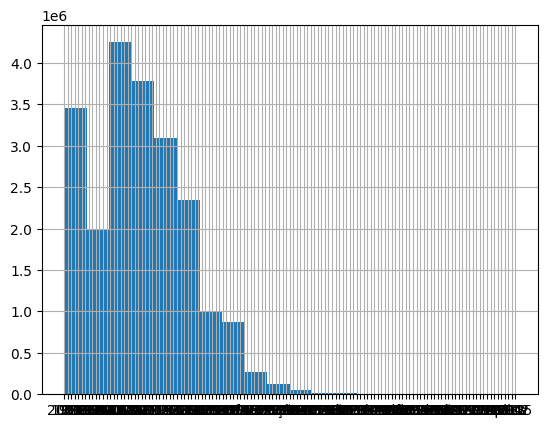

In [41]:
## Distribuição dos dados
df_frota['Ano_Fabricacao'].hist(bins=20)

<Axes: xlabel='UF', ylabel='Qtd_Veiculos'>

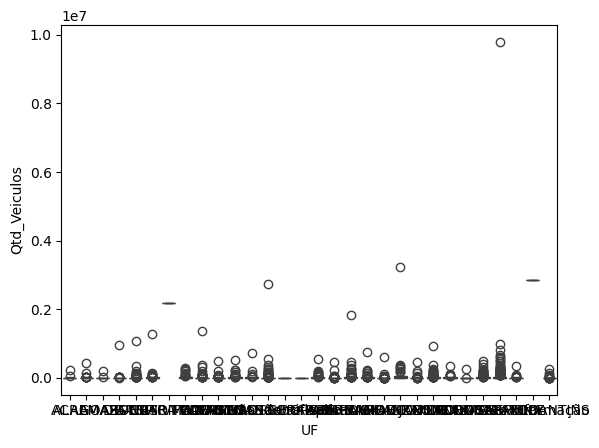

In [ ]:
import seaborn as sns

sns.boxplot(x='UF', y='Qtd_Veiculos', data=df_agrupado_municipio)


Proximos passos: 
- boxplot comparando a idade média dos veículos por estado brasileiro
- Mapa de calor para os municipios com maior densidade de frota
- criar correlações e mais análises de dados para traçar um perfil da frota de automóveis brasileira

Exportar o dataset limpo

In [31]:
# Salvar o dataset limpo em um novo arquivo CSV
df_frota.to_csv('datasets/frota_limpa.csv', index=False)

# Salvar o dataset limpo em um novo arquivo CSV
df_agrupado_municipio.to_csv('datasets/frota_municipio.csv', index=False)